In [1]:
import pandas as pd
import numpy as np
import seaborn as sb

df1 = pd.read_csv("fear_greed_index.csv")
df2 = pd.read_csv("historical_data.csv")

In [2]:
df1.head(5)

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [3]:
df2.head(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
## Shape of the dataset (rows and columns) and Basic information
print("Data 1:", df1.shape)
print("Data 2:", df2.shape)

print(df1.info())
print(df2.info())

Data 1: (2644, 4)
Data 2: (211224, 16)
<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    2

In [7]:
## Null values
print(df1.isnull().sum())
print(df2.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [8]:
## Duplicates
print(df1.duplicated().sum())
print(df2.duplicated().sum())

0
0


In [11]:
print(df1['date'].unique())

<StringArray>
['2018-02-01', '2018-02-02', '2018-02-03', '2018-02-04', '2018-02-05',
 '2018-02-06', '2018-02-07', '2018-02-08', '2018-02-09', '2018-02-10',
 ...
 '2025-04-23', '2025-04-24', '2025-04-25', '2025-04-26', '2025-04-27',
 '2025-04-28', '2025-04-29', '2025-04-30', '2025-05-01', '2025-05-02']
Length: 2644, dtype: str


In [15]:
## Converting the timestamps and aligning the datasets by date
df1['date'] = pd.to_datetime(df1['date'])
df2['Timestamp IST'] = pd.to_datetime(df2['Timestamp IST'], dayfirst=True)
df2['date'] = df2['Timestamp IST'].dt.date
df1['date'] = df1['date'].dt.date

print(df1['date'])
print(df2['date'])

merged = pd.merge(df1, df2, on='date', how='left')
merged

0       2018-02-01
1       2018-02-02
2       2018-02-03
3       2018-02-04
4       2018-02-05
           ...    
2639    2025-04-28
2640    2025-04-29
2641    2025-04-30
2642    2025-05-01
2643    2025-05-02
Name: date, Length: 2644, dtype: object
0         2024-12-02
1         2024-12-02
2         2024-12-02
3         2024-12-02
4         2024-12-02
             ...    
211219    2025-04-25
211220    2025-04-25
211221    2025-04-25
211222    2025-04-25
211223    2025-04-25
Name: date, Length: 211224, dtype: object


,timestamp,value,classification,date,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,1517463000,30,Fear,2018-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1517549400,15,Extreme Fear,2018-02-02,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1517635800,40,Fear,2018-02-03,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1517722200,24,Extreme Fear,2018-02-04,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1517808600,11,Extreme Fear,2018-02-05,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213378,1746077400,53,Neutral,2025-05-01,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,ETH,1805.6,5.0000,9028.00,SELL,2025-05-01 01:47:00,-476.4880,Open Short,0.0,0xb979fffcb79441fdd76404228f73930202a600839132...,9.006829e+10,True,3.159800,8.750000e+14,1.750000e+12
213379,1746077400,53,Neutral,2025-05-01,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,ETH,1805.6,8.8000,15889.28,SELL,2025-05-01 01:47:00,-481.4880,Open Short,0.0,0xb979fffcb79441fdd76404228f73930202a600839132...,9.006829e+10,True,5.561248,8.000000e+14,1.750000e+12
213380,1746077400,53,Neutral,2025-05-01,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,ETH,1805.6,14.1217,25498.14,SELL,2025-05-01 01:47:00,-490.2880,Open Short,0.0,0xb979fffcb79441fdd76404228f73930202a600839132...,9.006829e+10,True,8.924349,1.020000e+15,1.750000e+12
213381,1746077400,53,Neutral,2025-05-01,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,ETH,1805.6,5.4903,9913.29,SELL,2025-05-01 01:47:00,-504.4097,Open Short,0.0,0xb979fffcb79441fdd76404228f73930202a600839132...,9.006829e+10,True,3.469649,2.200000e+14,1.750000e+12


In [17]:
## Create the key metrics
# Daily PnL per Trader
daily_pnl = merged.groupby(['Account','date'])['Closed PnL'].sum().reset_index()
daily_pnl

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000
...,...,...,...
2335,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814


In [18]:
# Win Rate
merged['win'] = merged['Closed PnL'] > 0
winrate = merged.groupby('Account')['win'].mean()
winrate

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    0.359612
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    0.442720
0x271b280974205ca63b716753467d5a371de622ab    0.301917
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    0.438585
0x2c229d22b100a7beb69122eed721cee9b24011dd    0.519914
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    0.455215
0x39cef799f8b69da1995852eea189df24eb5cae3c    0.327668
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6    0.475904
0x420ab45e0bd8863569a5efbb9c05d91f40624641    0.234987
0x430f09841d65beb3f27765503d0f850b8bce7713    0.484236
0x47add9a56df66b524d5e2c1993a43cde53b6ed85    0.353445
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    0.486226
0x4f93fead39b70a1824f981a54d4e55b278e9f760    0.360364
0x513b8629fe877bb581bf244e326a047b249c4ff1    0.401193
0x6d6a4b953f202f8df5bed40692e7fd865318264a    0.431795
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    0.345912
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    0.303371
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    0.810876
0x

In [19]:
# Average Trade Size
avg_size = merged.groupby('Account')['Size USD'].mean()
avg_size

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    16159.576734
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     1653.226327
0x271b280974205ca63b716753467d5a371de622ab     8893.000898
0x28736f43f1e871e6aa8b1148d38d4994275d72c4      507.626933
0x2c229d22b100a7beb69122eed721cee9b24011dd     3138.894782
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891     1729.941104
0x39cef799f8b69da1995852eea189df24eb5cae3c     4790.575486
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6     3445.471265
0x420ab45e0bd8863569a5efbb9c05d91f40624641     5189.367128
0x430f09841d65beb3f27765503d0f850b8bce7713     2397.824753
0x47add9a56df66b524d5e2c1993a43cde53b6ed85      517.528924
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4     9084.699093
0x4f93fead39b70a1824f981a54d4e55b278e9f760    17098.171055
0x513b8629fe877bb581bf244e326a047b249c4ff1    34396.580284
0x6d6a4b953f202f8df5bed40692e7fd865318264a      746.725651
0x72743ae2822edd658c0c50608fd7c5c501b2afbd     7216.667245
0x72c6a4624e1dffa724e6d00d64ceae698af892a0     2

In [21]:
# Trades Per Day
trades_per_day = merged.groupby('date').size()
trades_per_day

date
2018-02-01       1
2018-02-02       1
2018-02-03       1
2018-02-04       1
2018-02-05       1
              ... 
2025-04-28    1379
2025-04-29    2243
2025-04-30    1113
2025-05-01    1230
2025-05-02       1
Length: 2644, dtype: int64

In [23]:
# Long Short Ratio
long_short_daily = merged.groupby(['date','Side']).size()
long_short_daily

date        Side
2023-05-01  BUY        3
2023-12-05  BUY        7
            SELL       2
2023-12-14  BUY        5
            SELL       6
                    ... 
2025-04-29  SELL    1138
2025-04-30  BUY      838
            SELL     275
2025-05-01  BUY      686
            SELL     544
Length: 881, dtype: int64

In [42]:
## PnL vs Sentiment
pnl_sentiment = merged.groupby('classification')['Closed PnL'].mean()
print(pnl_sentiment)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


In [27]:
## Win Rate vs Sentiment
win_sentiment = merged.groupby('classification')['win'].mean()

## Loss size:
drawdown = merged.groupby('classification')['Closed PnL'].min()

print(win_sentiment)
print(drawdown)

classification
Extreme Fear     0.362245
Extreme Greed    0.462491
Fear             0.416124
Greed            0.381491
Neutral          0.393555
Name: win, dtype: float64
classification
Extreme Fear     -31036.69194
Extreme Greed    -10259.46800
Fear             -35681.74723
Greed           -117990.10410
Neutral          -24500.00000
Name: Closed PnL, dtype: float64


In [28]:
## B2 Behavior vs Sentiment

## Trade Frequency
trades_freq = merged.groupby('classification').size()

## Trade Size
size_sentiment = merged.groupby('classification')['Size USD'].mean()

print(trades_freq)
print(size_sentiment)

classification
Extreme Fear     21894
Extreme Greed    40204
Fear             62527
Greed            50743
Neutral          38015
dtype: int64
classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


In [29]:
## Long Short Bias
bias = pd.crosstab(merged['classification'], merged['Side'])

## Fees (Proxy for activity)
fees = merged.groupby('classification')['Fee'].mean()

print(bias)
print(fees)

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717
classification
Extreme Fear     1.116291
Extreme Greed    0.675902
Fear             1.495172
Greed            1.254372
Neutral          1.044798
Name: Fee, dtype: float64


In [35]:
## Frequent vs Infrequent Traders
trader_counts = merged['Account'].value_counts()

active_traders = trader_counts[trader_counts > 50].index

merged['activity'] = merged['Account'].apply(
    lambda x: "High" if x in active_traders else "Low"
)

merged['activity']


0          Low
1          Low
2          Low
3          Low
4          Low
          ... 
213378    High
213379    High
213380    High
213381    High
213382     Low
Name: activity, Length: 213383, dtype: str

In [36]:
## Winners vs Losers
trader_pnl = merged.groupby('Account')['Closed PnL'].sum()

winners = trader_pnl[trader_pnl > 0].index

merged['trader_type'] = merged['Account'].apply(
    lambda x: "Winner" if x in winners else "Loser"
)

merged['trader_type']

0          Loser
1          Loser
2          Loser
3          Loser
4          Loser
           ...  
213378    Winner
213379    Winner
213380    Winner
213381    Winner
213382     Loser
Name: trader_type, Length: 213383, dtype: str

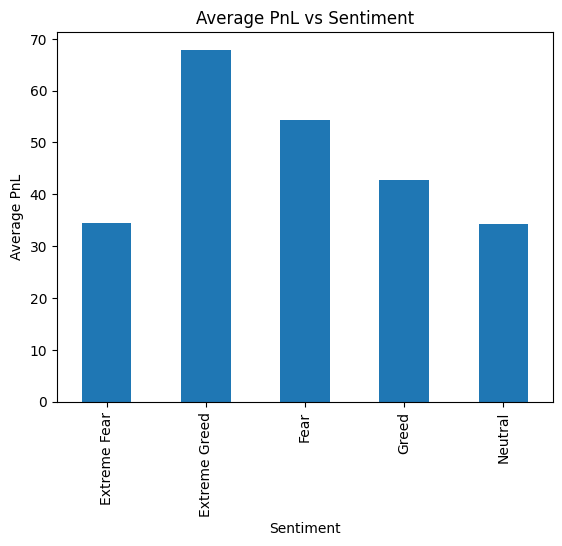

In [ ]:
## PnL vs Sentiment
## Shows whether traders make more profit during Fear or Greed.

import matplotlib.pyplot as plt

pnl_sentiment = merged.groupby('classification')['Closed PnL'].mean()
plt.figure()
pnl_sentiment.plot(kind='bar')
plt.title("Average PnL vs Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average PnL")
plt.show()

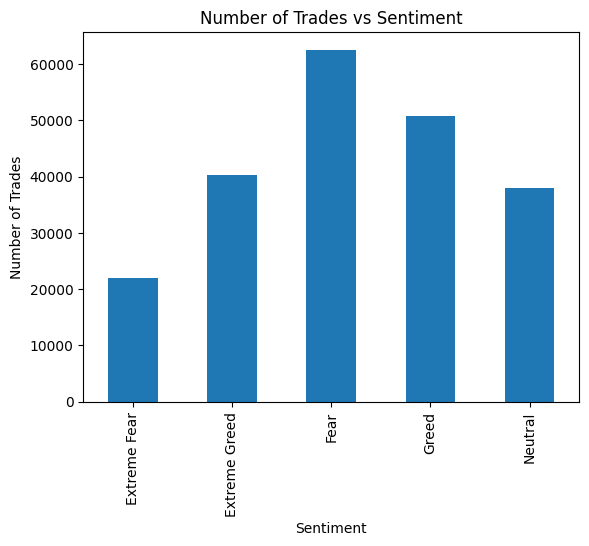

In [ ]:
## Trades vs Sentiment
## Shows how active traders are during Fear vs Greed.

trades_sentiment = merged.groupby('classification').size()
plt.figure()
trades_sentiment.plot(kind='bar')
plt.title("Number of Trades vs Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")
plt.show()

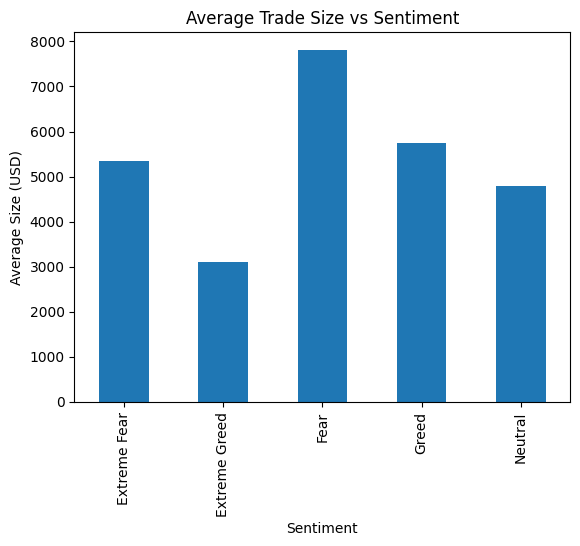

In [ ]:
## Trade Size vs Sentiment
## Shows if traders take bigger risks during Greed.

size_sentiment = merged.groupby('classification')['Size USD'].mean()
plt.figure()
size_sentiment.plot(kind='bar')
plt.title("Average Trade Size vs Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Size (USD)")
plt.show()

<Figure size 640x480 with 0 Axes>

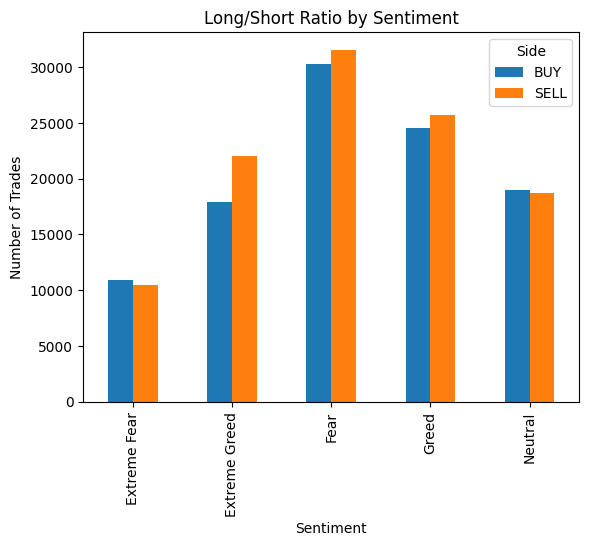

In [41]:
## Long/Short Ratio
## Shows trader direction bias.

long_short = merged.groupby(['classification', 'Side']).size().unstack()
plt.figure()
long_short.plot(kind='bar')
plt.title("Long/Short Ratio by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")
plt.show()

### Strategy 1: Risk Management Based on Sentiment

The analysis showed that trader losses were higher during Fear periods. This is likely due to increased market volatility and uncertainty. Therefore, traders should reduce leverage and position sizes during Fear periods to minimize risk.

#### Rule:

Fear → Reduce leverage and size

Greed → Normal trading


### Strategy 2: Trade Frequency Strategy

The analysis showed that trading activity increases during Greed periods. Traders may benefit from trading more during Greed periods and less during Fear periods.

#### Rule:

Fear → Fewer trades

Greed → More trades